In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

In [87]:
train = pd.read_csv('../data/train.csv', parse_dates=['date'])
test  = pd.read_csv('../data/test.csv',  parse_dates=['date'])

print('train:', train.shape)
print('test: ', test.shape)
train.head()

train: (913000, 4)
test:  (45000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Базовый анализ

In [88]:
# Типы данных и пропуски
print('=== Типы данных ===')
print(train.dtypes)
print()
print('=== Пропуски ===')
print(train.isnull().sum())

=== Типы данных ===
date     datetime64[us]
store             int64
item              int64
sales             int64
dtype: object

=== Пропуски ===
date     0
store    0
item     0
sales    0
dtype: int64


In [89]:
# Временные метки: диапазон и частота
print('=== Диапазон дат ===')
print(f'train: {train.date.min().date()} — {train.date.max().date()}')
print(f'test:  {test.date.min().date()} — {test.date.max().date()}')
print()

# Проверка что ряд непрерывный — нет пропущенных дат
expected = pd.date_range(train.date.min(), train.date.max(), freq='D')
n_series = train.store.nunique() * train.item.nunique()
print(f'=== Полнота ряда ===')
print(f'Магазинов: {train.store.nunique()}, Товаров: {train.item.nunique()}, Рядов: {n_series}')
print(f'Ожидаемых строк: {len(expected) * n_series}, фактических: {len(train)}')
print(f'Пропущенных дат: {len(expected) * n_series - len(train)}')

=== Диапазон дат ===
train: 2013-01-01 — 2017-12-31
test:  2018-01-01 — 2018-03-31

=== Полнота ряда ===
Магазинов: 10, Товаров: 50, Рядов: 500
Ожидаемых строк: 913000, фактических: 913000
Пропущенных дат: 0


In [90]:
# Описательная статистика по sales
train.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 12:00:00,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


## EDA

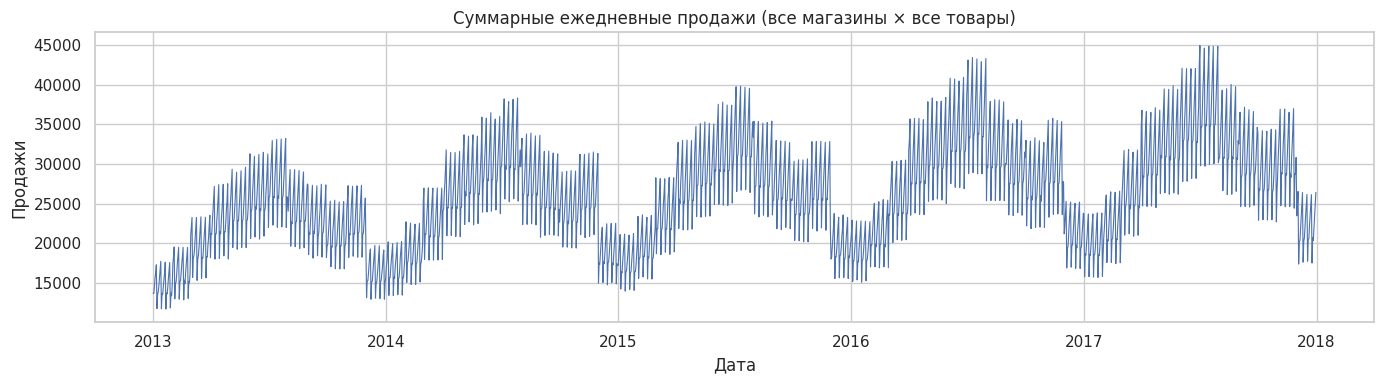

In [91]:
# Суммарные ежедневные продажи
daily = train.groupby('date')['sales'].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, linewidth=0.8)
ax.set_title('Суммарные ежедневные продажи (все магазины × все товары)')
ax.set_xlabel('Дата')
ax.set_ylabel('Продажи')
plt.tight_layout()
plt.show()

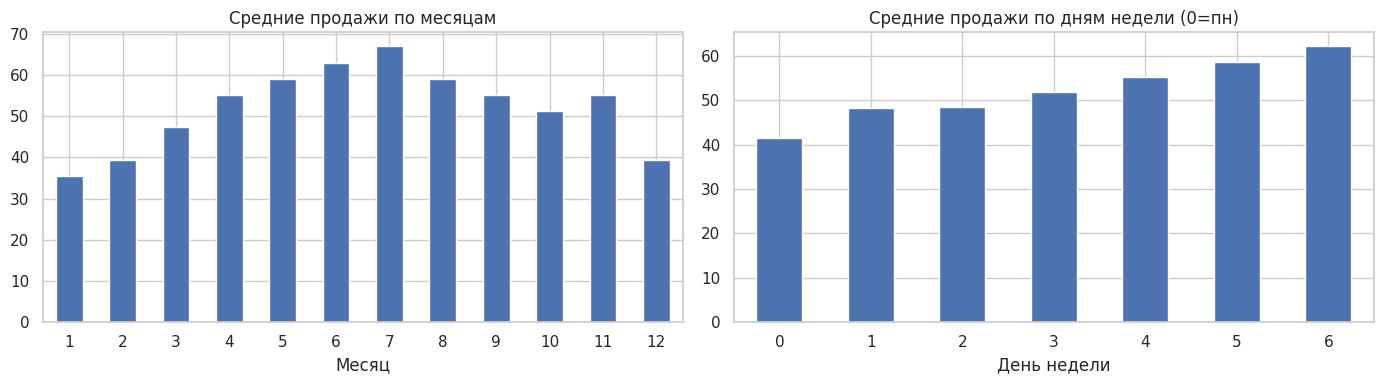

In [92]:
# Годовая и недельная сезонность
train['month'] = train['date'].dt.month
train['dayofweek'] = train['date'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train.groupby('month')['sales'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Средние продажи по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].tick_params(axis='x', rotation=0)

train.groupby('dayofweek')['sales'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Средние продажи по дням недели (0=пн)')
axes[1].set_xlabel('День недели')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Анализ одного ряда (store=1, item=1)

- амплидуда сезонных колебаний остается примерно постоянной, значит ряд можно описать аддитивной моделью.
- Тренд восходящий. Количество продаж в первом магазине для товара под первым индексом растет
- есть годовая сезонность с пиком в середине года (летом)
- есть недельная сезонность с уменьшением продаж  в период со вторника по среду

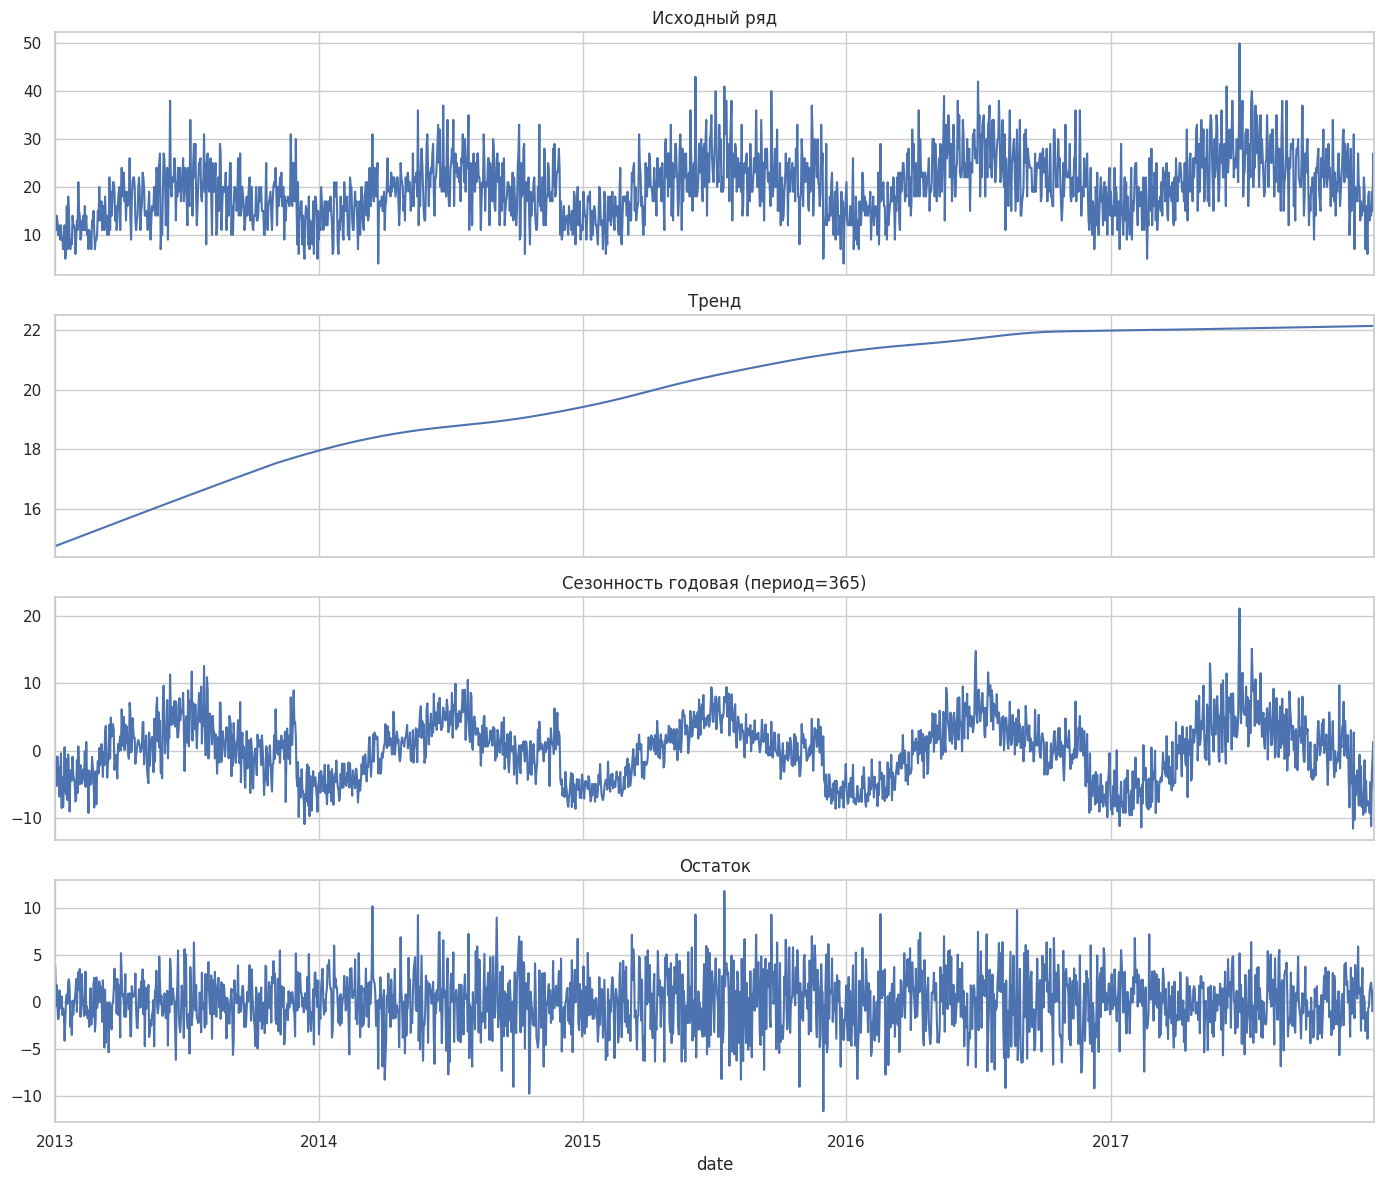

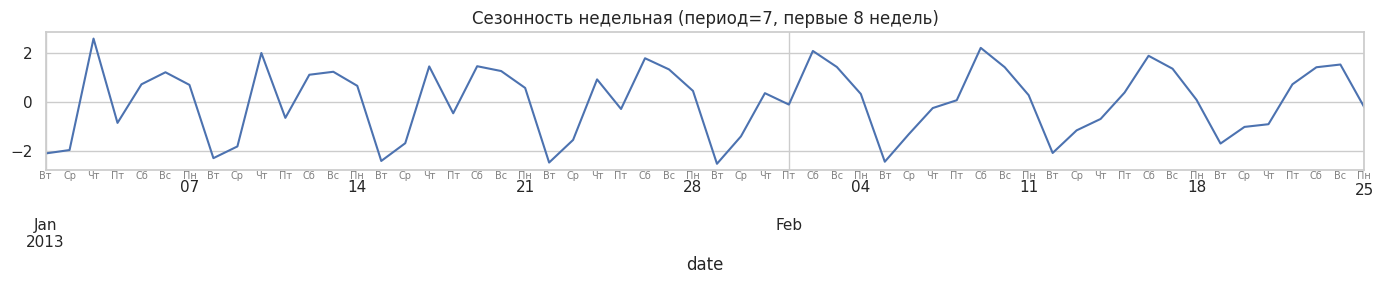

In [93]:
from statsmodels.tsa.seasonal import MSTL

ts = (train
      .query('store == 1 and item == 1')
      .set_index('date')['sales']
      .sort_index())

decomp = MSTL(ts, periods=(7, 365)).fit()

# Основная декомпозиция
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
decomp.observed.plot(ax=axes[0], title='Исходный ряд')
decomp.trend.plot(ax=axes[1], title='Тренд')
decomp.seasonal['seasonal_365'].plot(ax=axes[2], title='Сезонность годовая (период=365)')
decomp.resid.plot(ax=axes[3], title='Остаток')
plt.tight_layout()
plt.show()

# Недельная сезонность — первые 8 недель
s7 = decomp.seasonal['seasonal_7'].iloc[:56]
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

fig, ax = plt.subplots(figsize=(14, 3))
s7.plot(ax=ax, title='Сезонность недельная (период=7, первые 8 недель)')

y_min = s7.min()
for date, val in s7.items():
    ax.text(date, y_min - 0.3, day_names[date.dayofweek],
            ha='center', va='top', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

### Автокорреляция и частичная автокорреляция

- Затухание лага обусловлено трендом
- Пик на 7 день -- недельной сезонностью
- обрыв PACF на 7 день говорит о том, что для предсказания сегодняшних продаж достаточно знать продажи последних 7 дней

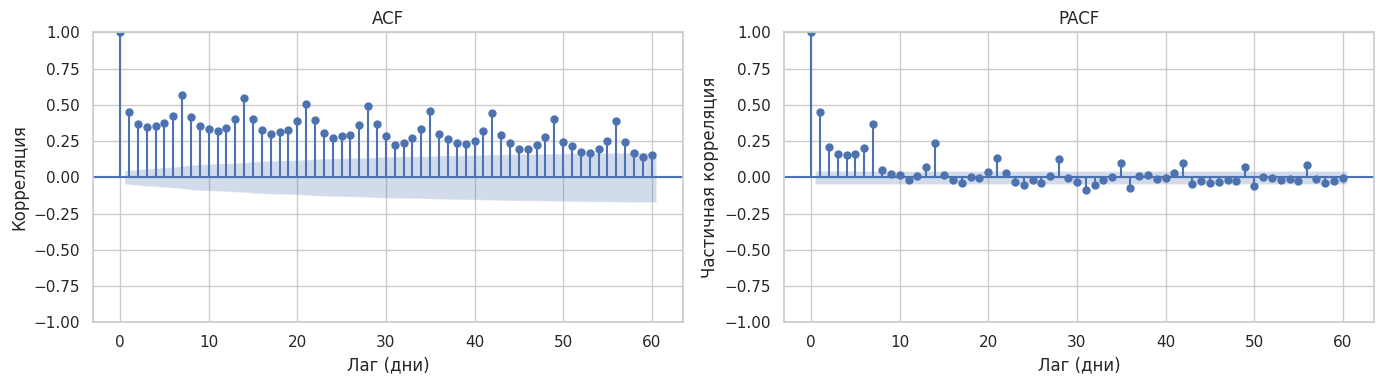

In [94]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts, lags=60, ax=axes[0])
axes[0].set_title('ACF')
axes[0].set_xlabel('Лаг (дни)')
axes[0].set_ylabel('Корреляция')

plot_pacf(ts, lags=60, ax=axes[1])
axes[1].set_title('PACF')
axes[1].set_xlabel('Лаг (дни)')
axes[1].set_ylabel('Частичная корреляция')

plt.tight_layout()
plt.show()

### Стационарность

Для исходного ряда ADF тест пройден, а KPSS тест не пройден. Значит ряд пограничный. У ряда имеется явный тренд. Вычитание предыдущего значения убирает тренд, поэтому после него оба теста проходят. Логарифм тут не влияет, поскольку модель ряда аддитивная

In [95]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_report(series, name):
    adf_p = adfuller(series.dropna(), autolag='AIC')[1]
    kpss_p = kpss(series.dropna(), regression='c')[1]
    adf_label  = 'стационарный' if adf_p  < 0.05 else 'не стационарный'
    kpss_label = 'стационарный' if kpss_p > 0.05 else 'не стационарный'
    print(f'--- {name} ---')
    print(f'ADF  p={adf_p:.4f}  → {adf_label}')
    print(f'KPSS p={kpss_p:.4f}  → {kpss_label}')
    print()

stationarity_report(ts,              'Исходный ряд')
stationarity_report(ts.diff(),       'Первая разность')
stationarity_report(np.log1p(ts),    'log(1+ts)')

--- Исходный ряд ---
ADF  p=0.0226  → стационарный
KPSS p=0.0100  → не стационарный

--- Первая разность ---
ADF  p=0.0000  → стационарный
KPSS p=0.1000  → стационарный

--- log(1+ts) ---
ADF  p=0.0066  → стационарный
KPSS p=0.0100  → не стационарный



## Статистические модели (Вариант А — statsforecast)

500 рядов (10 магазинов × 50 товаров) обрабатываются параллельно через `statsforecast`.  
Горизонт прогноза: **90 дней** (Q1 2018).  
Метрика: **SMAPE**.

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import (
    SeasonalNaive,
    AutoETS,
    AutoARIMA,
    Theta,
    AutoCES,
    DynamicOptimizedTheta,
)

H = 90  # горизонт прогноза

# Val-split: обучаем на всём кроме последних 90 дней, валидируем на них
cutoff = train['date'].max() - pd.Timedelta(days=H)
sf_train = (train.loc[train['date'] <= cutoff, ['store', 'item', 'date', 'sales']]
            .assign(unique_id=lambda df: df['store'].astype(str) + '_' + df['item'].astype(str))
            .rename(columns={'date': 'ds', 'sales': 'y'})
            [['unique_id', 'ds', 'y']])

sf_val = (train.loc[train['date'] > cutoff, ['store', 'item', 'date', 'sales']]
          .assign(unique_id=lambda df: df['store'].astype(str) + '_' + df['item'].astype(str))
          .rename(columns={'date': 'ds', 'sales': 'y_true'})
          [['unique_id', 'ds', 'y_true']])

print(f'Train до: {sf_train["ds"].max().date()}')
print(f'Val  с:   {sf_val["ds"].min().date()} по {sf_val["ds"].max().date()}')
print(f'Val строк: {len(sf_val)}')

In [ ]:
import time

H = 90  # горизонт прогноза

models = [
    SeasonalNaive(season_length=7),
    AutoETS(season_length=7),
    AutoARIMA(season_length=7),
    Theta(season_length=7),
    AutoCES(season_length=7),
    DynamicOptimizedTheta(season_length=7),
]

sf = StatsForecast(models=models, freq='D', n_jobs=-1)

start = time.time()
forecasts = sf.forecast(df=sf_train, h=H)
elapsed = time.time() - start

print(f'Готово за {elapsed:.1f} сек')
forecasts.head()

In [ ]:
results = forecasts.reset_index().merge(sf_val, on=['unique_id', 'ds'])

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.clip(np.asarray(y_pred), 0, None)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

model_cols = [c for c in forecasts.columns if c not in ['unique_id', 'ds']]
metrics_df = (pd.DataFrame([{'Модель': col, 'SMAPE': round(smape(results['y_true'], results[col]), 3)}
                             for col in model_cols])
              .sort_values('SMAPE')
              .reset_index(drop=True))
metrics_df

In [ ]:
# График 1: прогноз vs реальность на одном ряду (store=1, item=1)
uid = '1_1'
actual = sf_val[sf_val['unique_id'] == uid].set_index('ds')['y_true']
history = sf_train[sf_train['unique_id'] == uid].set_index('ds')['y'].iloc[-90:]

top_models = metrics_df['Модель'].tolist()
row = results[results['unique_id'] == uid].set_index('ds')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(history.index, history.values, color='gray', linewidth=0.8, label='История')
ax.plot(actual.index, actual.values, color='black', linewidth=1.5, label='Факт')

colors = plt.cm.tab10.colors
for i, model in enumerate(top_models):
    ax.plot(row.index, row[model].values, linewidth=1, color=colors[i], label=model, alpha=0.8)

ax.axvline(actual.index[0], color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Прогноз vs факт (store=1, item=1)')
ax.set_xlabel('Дата')
ax.set_ylabel('Продажи')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../graphs_output/stat_forecast_example.png', dpi=120)
plt.show()

# График 2: сравнение SMAPE по моделям
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(metrics_df['Модель'], metrics_df['SMAPE'], color=colors[:len(metrics_df)])
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlabel('SMAPE')
ax.set_title('Сравнение статистических моделей по SMAPE')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../graphs_output/stat_smape_comparison.png', dpi=120)
plt.show()

## ML модели (mlforecast)

In [ ]:
from mlforecast import MLForecast
from window_ops.rolling import rolling_mean, rolling_std
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

ml_train = sf_train.copy()
ml_val   = sf_val.copy()

mlf = MLForecast(
    models={
        'LinearRegression': LinearRegression(),
        'LightGBM': LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1),
        'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=0),
    },
    freq='D',
    lags=[1, 7, 14, 28, 91, 365],
    lag_transforms={
        7:  [(rolling_mean, 7), (rolling_std, 7)],
        28: [(rolling_mean, 28)],
    },
    date_features=['dayofweek', 'month', 'year'],
)

start = time.time()
mlf.fit(ml_train)
ml_elapsed = time.time() - start
print(f'Обучение: {ml_elapsed:.1f} сек')

In [ ]:
ml_forecasts = mlf.predict(H)
ml_results = ml_forecasts.merge(ml_val, on=['unique_id', 'ds'])

ml_model_cols = ['LinearRegression', 'LightGBM', 'XGBoost']
ml_metrics_df = (pd.DataFrame([
        {'Модель': col, 'SMAPE': round(smape(ml_results['y_true'], ml_results[col]), 3)}
        for col in ml_model_cols
    ])
    .sort_values('SMAPE')
    .reset_index(drop=True))

ml_metrics_df

In [ ]:
# График 1: прогноз ML vs факт (store=1, item=1)
uid = '1_1'
ml_actual  = ml_val[ml_val['unique_id'] == uid].set_index('ds')['y_true']
ml_history = ml_train[ml_train['unique_id'] == uid].set_index('ds')['y'].iloc[-90:]
ml_row     = ml_results[ml_results['unique_id'] == uid].set_index('ds')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ml_history.index, ml_history.values, color='gray', linewidth=0.8, label='История')
ax.plot(ml_actual.index, ml_actual.values, color='black', linewidth=1.5, label='Факт')
for i, model in enumerate(ml_model_cols):
    ax.plot(ml_row.index, ml_row[model].values, linewidth=1,
            color=plt.cm.tab10.colors[i], label=model, alpha=0.8)
ax.axvline(ml_actual.index[0], color='gray', linestyle='--', linewidth=0.8)
ax.set_title('ML модели: прогноз vs факт (store=1, item=1)')
ax.set_xlabel('Дата')
ax.set_ylabel('Продажи')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../graphs_output/ml_forecast_example.png', dpi=120)
plt.show()

# График 2: сравнение SMAPE (статистика + ML вместе)
all_metrics = pd.concat([metrics_df, ml_metrics_df]).sort_values('SMAPE').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['steelblue' if m in ml_model_cols else 'salmon' for m in all_metrics['Модель']]
bars = ax.barh(all_metrics['Модель'], all_metrics['SMAPE'], color=colors_bar)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlabel('SMAPE')
ax.set_title('Сравнение всех моделей по SMAPE  (синий = ML, красный = статистика)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../graphs_output/all_smape_comparison.png', dpi=120)
plt.show()

## DL модели (neuralforecast)

In [ ]:
import os, torch
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, TFT

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
print(f'Используется: {accelerator}')
if torch.cuda.is_available():
    print(f'VRAM свободно: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB')

nf_train = sf_train.copy()
nf_val   = sf_val.copy()

dl_model_cols = ['NBEATS', 'NHITS', 'TFT']
nf_results_list = []

dl_configs = [
    (NBEATS, 'NBEATS', dict(h=H, input_size=28, max_steps=50, batch_size=32)),
    (NHITS,  'NHITS',  dict(h=H, input_size=28, max_steps=50, batch_size=32)),
    (TFT,    'TFT',    dict(h=H, input_size=28, max_steps=50, batch_size=32, hidden_size=64)),
]

for ModelClass, name, kwargs in dl_configs:
    torch.cuda.empty_cache()
    print(f'Обучение {name}...')
    nf = NeuralForecast(models=[ModelClass(**kwargs, accelerator=accelerator)], freq='D')
    t0 = time.time()
    nf.fit(nf_train)
    preds = nf.predict().reset_index()
    preds = preds.merge(nf_val, on=['unique_id', 'ds'])
    nf_results_list.append(preds[['unique_id', 'ds', name, 'y_true']])
    print(f'  готово за {time.time()-t0:.1f} сек')
    del nf
    torch.cuda.empty_cache()

nf_results = nf_results_list[0]
for df in nf_results_list[1:]:
    nf_results = nf_results.merge(df.drop(columns='y_true'), on=['unique_id', 'ds'])

nf_results.head()

In [ ]:
nf_metrics_df = (pd.DataFrame([
        {'Модель': col, 'SMAPE': round(smape(nf_results['y_true'], nf_results[col]), 3)}
        for col in dl_model_cols
    ])
    .sort_values('SMAPE')
    .reset_index(drop=True))

print(nf_metrics_df.to_string(index=False))

In [ ]:
# График 1: прогноз DL vs факт (store=1, item=1)
uid = '1_1'
nf_actual  = nf_val[nf_val['unique_id'] == uid].set_index('ds')['y_true']
nf_history = nf_train[nf_train['unique_id'] == uid].set_index('ds')['y'].iloc[-90:]
nf_row     = nf_results[nf_results['unique_id'] == uid].set_index('ds')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(nf_history.index, nf_history.values, color='gray', linewidth=0.8, label='История')
ax.plot(nf_actual.index, nf_actual.values, color='black', linewidth=1.5, label='Факт')
for i, model in enumerate(dl_model_cols):
    ax.plot(nf_row.index, nf_row[model].values, linewidth=1,
            color=plt.cm.tab10.colors[i], label=model, alpha=0.8)
ax.axvline(nf_actual.index[0], color='gray', linestyle='--', linewidth=0.8)
ax.set_title('DL модели: прогноз vs факт (store=1, item=1)')
ax.set_xlabel('Дата')
ax.set_ylabel('Продажи')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../graphs_output/dl_forecast_example.png', dpi=120)
plt.show()

# График 2: финальное сравнение всех 12 моделей
final_metrics = (pd.concat([metrics_df, ml_metrics_df, nf_metrics_df])
                 .sort_values('SMAPE')
                 .reset_index(drop=True))

color_map = {**{m: 'salmon'     for m in model_cols},
             **{m: 'steelblue'  for m in ml_model_cols},
             **{m: 'seagreen'   for m in dl_model_cols}}
colors_final = [color_map.get(m, 'gray') for m in final_metrics['Модель']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(final_metrics['Модель'], final_metrics['SMAPE'], color=colors_final)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlabel('SMAPE')
ax.set_title('Итоговое сравнение всех моделей\n(красный = стат, синий = ML, зелёный = DL)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../graphs_output/final_smape_comparison.png', dpi=120)
plt.show()

print(final_metrics.to_string(index=False))

## Анализ остатков

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

uid = '1_1'
res = ml_results[ml_results['unique_id'] == uid].copy()
residuals = res['y_true'].values - res['XGBoost'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(res['ds'].values, residuals, linewidth=0.8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('Остатки XGBoost (store=1, item=1)')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Остаток')

plot_acf(residuals, lags=30, ax=axes[1])
axes[1].set_title('ACF остатков XGBoost')

plt.tight_layout()
plt.savefig('../graphs_output/residuals_analysis.png', dpi=120)
plt.show()

lb = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print('Тест Льюнга–Бокса (H0: нет автокорреляции в остатках):')
print(lb.round(4))
if (lb['lb_pvalue'] < 0.05).any():
    print('\nВывод: p < 0.05 — в остатках есть автокорреляция, модель не полностью описывает структуру ряда')
else:
    print('\nВывод: p > 0.05 — автокорреляция незначима, модель адекватна')

## Бэктест (rolling-origin)

In [ ]:
# Полный ряд для бэктеста
sf_full = (train[['store', 'item', 'date', 'sales']]
           .assign(unique_id=lambda df: df['store'].astype(str) + '_' + df['item'].astype(str))
           .rename(columns={'date': 'ds', 'sales': 'y'})
           [['unique_id', 'ds', 'y']])

cv_sf = StatsForecast(
    models=[
        SeasonalNaive(season_length=7),
        DynamicOptimizedTheta(season_length=7),
    ],
    freq='D',
    n_jobs=-1,
)

t0 = time.time()
cv_df = cv_sf.cross_validation(df=sf_full, h=H, n_windows=3, step_size=H)
print(f'Бэктест: {time.time()-t0:.1f} сек')
cv_df.head()

In [ ]:
cv_model_cols = ['SeasonalNaive', 'DynamicOptimizedTheta']

rows = []
for cutoff, grp in cv_df.groupby('cutoff'):
    for col in cv_model_cols:
        rows.append({'Cutoff': cutoff.date(), 'Модель': col,
                     'SMAPE': round(smape(grp['y'], grp[col]), 3)})
cv_metrics_df = pd.DataFrame(rows)

pivot = cv_metrics_df.pivot(index='Cutoff', columns='Модель', values='SMAPE')
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
for col in cv_model_cols:
    ax.plot(pivot.index.astype(str), pivot[col], marker='o', label=col)
ax.set_title('SMAPE по окнам бэктеста (rolling-origin, n_windows=3)')
ax.set_xlabel('Cutoff')
ax.set_ylabel('SMAPE')
ax.legend()
plt.tight_layout()
plt.savefig('../graphs_output/backtest_smape.png', dpi=120)
plt.show()

## Вероятностные оценки (предиктивные интервалы)

In [ ]:
sf_pi = StatsForecast(
    models=[DynamicOptimizedTheta(season_length=7)],
    freq='D',
    n_jobs=-1,
)
forecasts_pi = sf_pi.forecast(df=sf_train, h=H, level=[80, 95])
forecasts_pi.head()

In [ ]:
# Fan chart для store=1, item=1
uid = '1_1'
pi = forecasts_pi.reset_index()
pi_row = pi[pi['unique_id'] == uid]
actual = sf_val[sf_val['unique_id'] == uid]
history = sf_train[sf_train['unique_id'] == uid].tail(90)

model = 'DynamicOptimizedTheta'
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(history['ds'], history['y'], color='gray', linewidth=0.8, label='История')
ax.plot(actual['ds'], actual['y_true'], color='black', linewidth=1.5, label='Факт')
ax.plot(pi_row['ds'], pi_row[model], color='steelblue', linewidth=1.5, label='Прогноз (DOT)')
ax.fill_between(pi_row['ds'], pi_row[f'{model}-lo-95'], pi_row[f'{model}-hi-95'],
                alpha=0.15, color='steelblue', label='95% интервал')
ax.fill_between(pi_row['ds'], pi_row[f'{model}-lo-80'], pi_row[f'{model}-hi-80'],
                alpha=0.30, color='steelblue', label='80% интервал')
ax.axvline(actual['ds'].iloc[0], color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Вероятностный прогноз DynamicOptimizedTheta (store=1, item=1)')
ax.set_xlabel('Дата')
ax.set_ylabel('Продажи')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../graphs_output/prediction_intervals.png', dpi=120)
plt.show()

# Эмпирическое покрытие по всем 500 рядам
pi_all = forecasts_pi.reset_index().merge(sf_val, on=['unique_id', 'ds'])
for level in [80, 95]:
    lo, hi = f'{model}-lo-{level}', f'{model}-hi-{level}'
    cov = ((pi_all['y_true'] >= pi_all[lo]) & (pi_all['y_true'] <= pi_all[hi])).mean()
    print(f'Покрытие {level}%: {cov:.3f}  (номинал {level/100:.2f})')